# Praktikum EDA — Topik Dalam Data Mining

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GIGA-TDDM/Template-Praktikum-EDA/blob/main/notebooks/praktikum01_eda.ipynb)

**EF235161 Topik Dalam Data Mining (P) — S-2 Teknik Informatika, ITS**
Exploratory Data Analysis, Data Preprocessing & Experimental Validity · sesi 120 menit

---

## Isi identitas Anda

| | |
|---|---|
| **Nama** | _(isi)_ |
| **NRP** | _(isi)_ |
| **Username GitHub** | _(isi)_ |

---

## Cara menyimpan pekerjaan Anda

Bekerja di Colab: **File → Save a copy in GitHub**, pilih repositori praktikum Anda, isi pesan commit. Ulangi setiap kali Anda ingin menyimpan — itulah commit Anda.

Bekerja lokal: `git add`, `git commit`, `git push` seperti biasa.

---

## Aturan sesi

- Jalankan sel **berurutan dari atas**. Jangan melompat.
- Setiap kali menjalankan sel, tulis satu kalimat interpretasi di sel Markdown di bawahnya. Menjalankan kode tanpa interpretasi berarti belum mengerjakan praktikum.
- Dataset `customer_churn_eda.csv` **sengaja dibuat cacat**. Tugas Anda menemukan cacatnya lewat bukti, lalu mempertanggungjawabkan setiap keputusan.
- Temuan akhir dituliskan di `laporan/LAPORAN.md`.

> **Pesan utama:** EDA bukan kegiatan membuat grafik. EDA adalah proses mengumpulkan bukti untuk mengambil keputusan preprocessing dan menjaga validitas eksperimen.

## Blok 0 — Setup & reproducibility

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 50)

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("RANDOM_STATE:", RANDOM_STATE)

Python      : 3.13.15
NumPy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1
RANDOM_STATE: 42


Sel berikut memuat dataset secara otomatis dengan tiga lapis fallback: file lokal di `data/`, lalu URL repositori, lalu dialog upload. Anda tidak perlu mengatur apa pun.

Bila Anda ingin bekerja langsung di dalam klon repositori Anda sendiri, jalankan dulu:

```python
!git clone https://github.com/GIGA-TDDM/Template-Praktikum-EDA.git
%cd Template-Praktikum-EDA
```

In [2]:
import os, io, urllib.request

# Repositori TEMPLATE yang publik — sumber dataset saat notebook dibuka di Colab
# tanpa klon repositori. Repositori mahasiswa umumnya privat, sehingga URL raw-nya
# tidak dapat diakses; karena itu nama di bawah ini sengaja TIDAK ikut diganti
# oleh workflow inisialisasi. Ubah hanya bila nama repositori template berubah.
REPO_TEMPLATE = "GIGA-TDDM/Template-Praktikum-EDA"
DATA_URL = f"https://raw.githubusercontent.com/{REPO_TEMPLATE}/main/data/customer_churn_eda.csv"

DATA_LOKAL = ("data/customer_churn_eda.csv",
              "../data/customer_churn_eda.csv",
              "customer_churn_eda.csv")


def muat_dataset():
    """Tiga lapis: file lokal -> URL repositori template -> dialog upload Colab."""
    for p in DATA_LOKAL:
        if os.path.exists(p):
            print(f"Sumber: file lokal '{p}'")
            return pd.read_csv(p)
    try:
        print(f"Sumber: {DATA_URL}")
        with urllib.request.urlopen(DATA_URL, timeout=20) as r:
            return pd.read_csv(io.BytesIO(r.read()))
    except Exception as e:
        print("Gagal memuat dari URL:", e)
        print("Silakan unggah customer_churn_eda.csv secara manual.")
        from google.colab import files
        files.upload()
        return pd.read_csv("customer_churn_eda.csv")


df = muat_dataset()
print("Ukuran dataset:", df.shape)
df.head()

Sumber: https://raw.githubusercontent.com/GIGA-TDDM/Template-Praktikum-EDA/main/data/customer_churn_eda.csv
Ukuran dataset: (3012, 15)


,customer_id,age,monthly_income,tenure_months,monthly_spend,transactions_per_month,support_tickets,satisfaction_score,city,segment,channel,premium_member,annual_spend,churn_next_month_confirmed,churn
0,C000001,42,NaN,30.7,1783229.0,4,2,4.0,Surabaya,Gold,Branch,1,21398745.0,0,0
1,C000002,26,11677597.0,46.4,945542.0,3,1,3.0,Jakarta,Basic,App,0,11346502.0,0,0
2,C000003,47,23589735.0,11.3,3510855.0,2,0,4.0,Surabaya,Gold,App,1,42130261.0,0,0
3,C000004,49,3414850.0,22.7,317268.0,6,3,4.0,Makassar,Basic,App,0,3807220.0,0,0
4,C000005,18,6913621.0,5.6,628647.0,7,1,4.0,Surabaya,Silver,App,0,7543770.0,0,0


## Blok 1 — Struktur dataset

Pertanyaan pertama peneliti: **satu baris di dataset ini merepresentasikan apa?**

In [3]:
df.info()
print("\nJumlah baris  :", len(df))
print("Jumlah kolom  :", df.shape[1])
print("customer_id unik:", df["customer_id"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012 entries, 0 to 3011
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 3012 non-null   object 
 1   age                         3012 non-null   int64  
 2   monthly_income              2801 non-null   float64
 3   tenure_months               3012 non-null   float64
 4   monthly_spend               3012 non-null   float64
 5   transactions_per_month      3012 non-null   int64  
 6   support_tickets             3012 non-null   int64  
 7   satisfaction_score          2922 non-null   float64
 8   city                        2890 non-null   object 
 9   segment                     3012 non-null   object 
 10  channel                     3012 non-null   object 
 11  premium_member              3012 non-null   int64  
 12  annual_spend                3012 non-null   float64
 13  churn_next_month_confirmed  3012 

**Interpretasi Anda:** _(jumlah baris vs jumlah ID unik — apa dugaan Anda?)_

## Blok 2 — Tipe fitur: *file type* vs *semantic type*

`premium_member` bertipe `int64`, tetapi maknanya kategori biner. Perbedaan inilah sumber kesalahan preprocessing paling umum.

In [4]:
profil = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
})
profil

,dtype,n_unique,n_missing,pct_missing
customer_id,object,3000,0,0.00
age,int64,57,0,0.00
monthly_income,float64,2785,211,7.01
tenure_months,float64,761,0,0.00
monthly_spend,float64,2999,0,0.00
transactions_per_month,int64,14,0,0.00
support_tickets,int64,8,0,0.00
satisfaction_score,float64,5,90,2.99
city,object,7,122,4.05
segment,object,3,0,0.00


**Tugas kecil:** sebutkan kolom yang TIDAK boleh menjadi fitur input, beserta alasannya.

## Blok 3 — Missing values

Yang penting bukan berapa persen yang hilang, tetapi **mengapa** hilang (MCAR / MAR / MNAR).

In [5]:
miss = (pd.DataFrame({"n_missing": df.isna().sum(),
                      "pct": (df.isna().mean()*100).round(2)})
          .query("n_missing > 0").sort_values("pct", ascending=False))
print(miss)

for c in miss.index:
    print(f"\n{c} — churn rate saat nilai ada vs missing:")
    print(df.groupby(df[c].isna())["churn"].mean().rename({False: "ada nilai", True: "missing"}).round(4))

                    n_missing   pct
monthly_income            211  7.01
city                      122  4.05
satisfaction_score         90  2.99

monthly_income — churn rate saat nilai ada vs missing:
monthly_income
ada nilai    0.1810
missing      0.1564
Name: churn, dtype: float64

city — churn rate saat nilai ada vs missing:
city
ada nilai    0.1803
missing      0.1557
Name: churn, dtype: float64

satisfaction_score — churn rate saat nilai ada vs missing:
satisfaction_score
ada nilai    0.1800
missing      0.1556
Name: churn, dtype: float64


**Catatan:** jangan `dropna()`. Imputasi dilakukan **di dalam pipeline, setelah split** (alasannya di Blok 9).

## Blok 4 — Duplikat & inkonsistensi kategori

In [6]:
print("Duplikat baris penuh :", df.duplicated().sum())
print("Duplikat customer_id :", df["customer_id"].duplicated().sum())

for c in ["city", "segment", "channel"]:
    print(f"\n--- {c} ---")
    print(df[c].value_counts(dropna=False))

Duplikat baris penuh : 12
Duplikat customer_id : 12

--- city ---
city
Surabaya    1427
Jakarta      744
Bandung      406
Makassar     286
NaN          122
surabaya      16
jakarta        7
bandung        4
Name: count, dtype: int64

--- segment ---
segment
Basic     1652
Silver     930
Gold       430
Name: count, dtype: int64

--- channel ---
channel
App       1691
Web        865
Branch     456
Name: count, dtype: int64


Perbaikan berikut **deterministik** (tidak belajar apa pun dari data), sehingga aman dilakukan sebelum split.
Bandingkan dengan imputasi median, yang dihitung dari data dan karenanya **harus** setelah split.

In [7]:
df_clean = df.drop_duplicates().copy()
for c in ["city", "segment", "channel"]:
    df_clean[c] = df_clean[c].str.strip().str.title()

print("Ukuran setelah dedup:", df_clean.shape)
print(df_clean["city"].value_counts(dropna=False))

Ukuran setelah dedup: (3000, 15)
city
Surabaya    1440
Jakarta      747
Bandung      408
Makassar     285
NaN          120
Name: count, dtype: int64


## Blok 5 — Distribusi target & statistik deskriptif

In [8]:
print(df_clean["churn"].value_counts())
print(df_clean["churn"].value_counts(normalize=True).round(4))

num_cols = ["age","monthly_income","tenure_months","monthly_spend",
            "transactions_per_month","support_tickets","satisfaction_score"]
print("\n--- Skewness ---")
print(df_clean[num_cols].skew().sort_values(ascending=False).round(2))
df_clean[num_cols].describe().T

churn
0    2462
1     538
Name: count, dtype: int64
churn
0    0.8207
1    0.1793
Name: proportion, dtype: float64

--- Skewness ---
monthly_spend             7.14
monthly_income            5.56
tenure_months             1.22
support_tickets           0.77
transactions_per_month    0.43
age                       0.21
satisfaction_score       -0.09
dtype: float64


,count,mean,std,min,25%,50%,75%,max
age,3000.0,3.798100e+01,1.152372e+01,18.0,30.00,38.0,46.0,75.0
monthly_income,2790.0,9.786744e+06,7.643647e+06,1500000.0,5562421.25,8137317.5,11783552.5,112404078.0
tenure_months,3000.0,3.069513e+01,2.064728e+01,0.4,15.70,26.1,41.2,120.0
monthly_spend,3000.0,1.094514e+06,7.793079e+05,145157.0,689729.25,945020.5,1307367.0,14407976.0
transactions_per_month,3000.0,4.149667e+00,2.046296e+00,0.0,3.00,4.0,5.0,13.0
support_tickets,3000.0,1.518333e+00,1.234844e+00,0.0,1.00,1.0,2.0,7.0
satisfaction_score,2910.0,3.212715e+00,9.460034e-01,1.0,3.00,3.0,4.0,5.0


**Dua angka yang menentukan seluruh desain eksperimen:**
1. Imbalance kelas → accuracy dilarang jadi metrik utama; split harus `stratify`.
2. Skewness ekstrem pada fitur nominal Rupiah → log-transform sebelum scaling.

## Blok 6 — Outlier (aturan IQR)

Outlier **tidak otomatis dibuang**. Buang hanya bila ada alasan domain bahwa nilainya mustahil.

monthly_income         outlier:  136 (4.5%)  batas atas: 21,115,249
monthly_spend          outlier:  137 (4.6%)  batas atas: 2,233,824
tenure_months          outlier:   90 (3.0%)  batas atas: 79


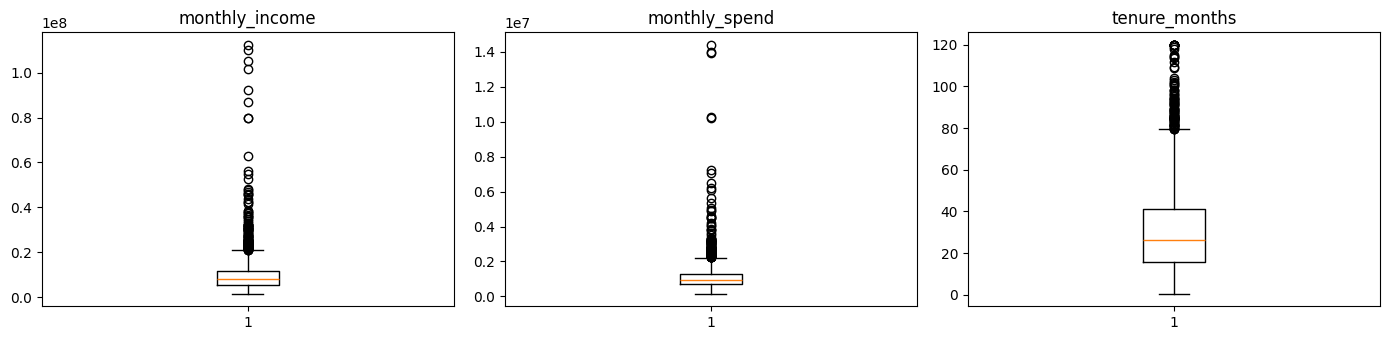

In [9]:
for c in ["monthly_income", "monthly_spend", "tenure_months"]:
    q1, q3 = df_clean[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df_clean[c] < lo) | (df_clean[c] > hi)
    print(f"{c:22s} outlier: {mask.sum():4d} ({mask.mean()*100:.1f}%)  batas atas: {hi:,.0f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for a, c in zip(ax, ["monthly_income", "monthly_spend", "tenure_months"]):
    a.boxplot(df_clean[c].dropna()); a.set_title(c)
plt.tight_layout(); plt.show()

## Blok 7 — Bivariate analysis terhadap target

EDA menghasilkan **asosiasi**, bukan **kausalitas**. Perhatikan pilihan kata saat menulis temuan.

In [10]:
display(df_clean.groupby("churn")[num_cols].median().T.round(2))

for c in ["segment", "channel", "city", "premium_member"]:
    print(f"\n--- {c} ---")
    print(df_clean.groupby(c)["churn"].agg(churn_rate="mean", n="count").round(3))

churn,0,1
age,38.0,37.0
monthly_income,8138368.0,8132352.0
tenure_months,26.2,25.4
monthly_spend,950840.5,937640.5
transactions_per_month,4.0,4.0
support_tickets,1.0,2.0
satisfaction_score,3.0,3.0



--- segment ---
         churn_rate     n
segment                  
Basic         0.218  1645
Gold          0.140   429
Silver        0.130   926

--- channel ---
         churn_rate     n
channel                  
App           0.162  1684
Branch        0.231   455
Web           0.186   861

--- city ---
          churn_rate     n
city                      
Bandung        0.179   408
Jakarta        0.170   747
Makassar       0.161   285
Surabaya       0.190  1440

--- premium_member ---
                churn_rate     n
premium_member                  
0                    0.188  2539
1                    0.130   461


Boleh ditulis: *"Segmen Basic menunjukkan churn rate lebih tinggi."*
Tidak boleh: *"Segmen Basic menyebabkan churn."*

## Blok 8 — Korelasi: menemukan *redundant feature* dan *leakage*

Bagian terpenting sesi ini. Cari nilai yang terlalu bagus untuk jadi kenyataan.

In [11]:
kandidat = num_cols + ["premium_member", "annual_spend", "churn_next_month_confirmed", "churn"]
print(df_clean[kandidat].corr()["churn"].sort_values(ascending=False).round(4))

churn_next_month_confirmed    1.0000
churn                         1.0000
support_tickets               0.1880
monthly_income                0.0159
monthly_spend                -0.0015
annual_spend                 -0.0015
transactions_per_month       -0.0032
tenure_months                -0.0305
age                          -0.0485
premium_member               -0.0546
satisfaction_score           -0.1933
Name: churn, dtype: float64


In [12]:
print(pd.crosstab(df_clean["churn_next_month_confirmed"], df_clean["churn"]))
print("\nKorelasi monthly_spend vs annual_spend:",
      round(df_clean[["monthly_spend","annual_spend"]].corr().iloc[0,1], 6))
print("\nRasio annual_spend / monthly_spend:")
print((df_clean["annual_spend"] / df_clean["monthly_spend"]).describe().round(3))

churn                          0    1
churn_next_month_confirmed           
0                           2462    0
1                              0  538

Korelasi monthly_spend vs annual_spend: 1.0

Rasio annual_spend / monthly_spend:
count    3000.0
mean       12.0
std         0.0
min        12.0
25%        12.0
50%        12.0
75%        12.0
max        12.0
dtype: float64


**Dua temuan, dua jenis masalah:**

- `annual_spend` = `monthly_spend` x 12 → **redundant feature**: tidak menambah informasi, merusak interpretasi koefisien.
- `churn_next_month_confirmed` identik dengan target → **target leakage**: informasi masa depan yang tidak tersedia saat prediksi harus dibuat.

Uji deteksi leakage bukan statistik, melainkan pertanyaan:
> *"Pada saat prediksi harus dibuat, apakah nilai kolom ini sudah tersedia?"*

---
## CHECKPOINT — Tulis 5 temuan EDA Anda di sini

Format wajib setiap temuan: **Temuan → Bukti (angka/sel mana) → Implikasi terhadap preprocessing atau validitas.**

1. *Temuan:* ... *Bukti:* ... *Implikasi:* ...
2.
3.
4.
5.

---

## Blok 9 — Keputusan preprocessing & split

| Keputusan | Bukti dari EDA |
|---|---|
| Drop `customer_id` | identifier, n_unique = n_baris (Blok 2) |
| Drop `annual_spend` | redundant, korelasi 1.0 (Blok 8) |
| Drop `churn_next_month_confirmed` | target leakage (Blok 8) |
| Hapus 12 duplikat | Blok 4 |
| Normalisasi string kategori | Blok 4 |
| Imputasi median / modus | Blok 3 |
| Log1p pada fitur skewed | Blok 5 |
| `stratify=y` | Blok 5 |
| Metrik utama PR-AUC | Blok 5 |

In [13]:
from sklearn.model_selection import train_test_split

DROP = ["customer_id", "annual_spend", "churn_next_month_confirmed"]
X = df_clean.drop(columns=DROP + ["churn"])
y = df_clean["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| churn rate:", round(y_train.mean(), 4))
print("Test :", X_test.shape,  "| churn rate:", round(y_test.mean(), 4))

Train: (2400, 11) | churn rate: 0.1792
Test : (600, 11) | churn rate: 0.18


> **Mulai titik ini test set dikunci.** Tidak dilihat, tidak dipakai memilih model. Dibuka satu kali di Blok 11b.

## Blok 10 — Preprocessing pipeline & baseline

Pipeline memaksa imputer dan scaler belajar **hanya dari fold training** di setiap lipatan CV. Ini alat penjaga validitas, bukan sekadar kerapian kode.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

skewed   = ["monthly_income", "monthly_spend"]
numerik  = ["age", "tenure_months", "transactions_per_month",
            "support_tickets", "satisfaction_score", "premium_member"]
kategori = ["city", "segment", "channel"]

pipe_skewed = Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                        ("scaler", StandardScaler())])
pipe_numerik = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
pipe_kategori = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))])

pre = ColumnTransformer([("skewed", pipe_skewed, skewed),
                         ("numerik", pipe_numerik, numerik),
                         ("kategori", pipe_kategori, kategori)])

model = Pipeline([("pre", pre),
                  ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                             random_state=RANDOM_STATE))])
model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('skewed',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['monthly_income',
                                                   'monthly_spend']),
                                                 ('numerik',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scal...
                                                  ['age', 'tenure_months',
                                                   'transactions_per_month',
                                                   'support_tickets',
                                                   'satisfaction_score',
                                                   'premium_member']),
                                                 ('kategori',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'segment',
                                                   'channel'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [15]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Accuracy DummyClassifier di test set:", round(dummy.score(X_test, y_test), 4))

Accuracy DummyClassifier di test set: 0.82


Ingat angka baseline ini. Model yang akurasinya di bawah angka ini kalah dari menebak kelas mayoritas.

## Blok 11 — Cross-validation pada training set

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
           "f1": "f1", "accuracy": "accuracy"}

hasil = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
for m in scoring:
    s = hasil["test_" + m]
    print(f"{m:10s}: {s.mean():.3f} +/- {s.std():.3f}")

roc_auc   : 0.674 +/- 0.026
pr_auc    : 0.345 +/- 0.031
f1        : 0.373 +/- 0.020
accuracy  : 0.641 +/- 0.017


Accuracy di bawah baseline dummy adalah **konsekuensi desain** `class_weight="balanced"`, bukan kegagalan model.
Selalu laporkan rata-rata **beserta** standar deviasinya.

### Blok 11b — Evaluasi final (test set dibuka satu kali)

In [17]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred  = model.predict(X_test)

print("ROC-AUC :", round(roc_auc_score(y_test, proba), 3))
print("PR-AUC  :", round(average_precision_score(y_test, proba), 3))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\n", classification_report(y_test, pred, digits=3))

ROC-AUC : 0.717
PR-AUC  : 0.391

Confusion matrix:
 [[317 175]
 [ 34  74]]

               precision    recall  f1-score   support

           0      0.903     0.644     0.752       492
           1      0.297     0.685     0.415       108

    accuracy                          0.652       600
   macro avg      0.600     0.665     0.583       600
weighted avg      0.794     0.652     0.691       600



## Blok 12 — Demonstrasi *experimental validity*: apa yang terjadi bila leakage ikut dilatih?

Sebelum menjalankan sel di bawah, **tebak dulu** berapa ROC-AUC-nya.

In [18]:
X_leak = df_clean.drop(columns=["customer_id", "annual_spend", "churn"])
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leak, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

pre_leak = ColumnTransformer([
    ("skewed", pipe_skewed, skewed),
    ("numerik", pipe_numerik, numerik + ["churn_next_month_confirmed"]),
    ("kategori", pipe_kategori, kategori)])
model_leak = Pipeline([("pre", pre_leak),
                       ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                  random_state=RANDOM_STATE))])

model_leak.fit(Xl_tr, yl_tr)
print("ROC-AUC test dengan leakage :", round(roc_auc_score(yl_te, model_leak.predict_proba(Xl_te)[:, 1]), 4))

cv_leak = cross_validate(model_leak, Xl_tr, yl_tr, cv=cv, scoring={"roc_auc": "roc_auc"})
print("ROC-AUC CV  dengan leakage :", round(cv_leak["test_roc_auc"].mean(), 4))
print("Bandingkan dengan model jujur di Blok 11b.")

ROC-AUC test dengan leakage : 1.0
ROC-AUC CV  dengan leakage : 1.0
Bandingkan dengan model jujur di Blok 11b.


**Perhatikan:** cross-validation pun menunjukkan nilai sempurna.
CV melindungi dari *overfitting*, **bukan** dari *target leakage*. Satu-satunya pertahanan adalah memahami asal-usul setiap kolom.

> Bila model Anda tiba-tiba mendapat AUC ~0.99 pada data nyata, reaksi pertama yang benar adalah **mencari leakage**, bukan menulis paper.

## Blok 13 — Reproducibility log

In [19]:
log = {
    "random_state": RANDOM_STATE,
    "n_raw": len(df),
    "n_after_dedup": len(df_clean),
    "dropped_features": DROP,
    "n_train": len(X_train), "n_test": len(X_test),
    "cv": "StratifiedKFold(5, shuffle=True)",
    "primary_metric": "PR-AUC (average_precision)",
    "python": sys.version.split()[0], "sklearn": sklearn.__version__,
}
for k, v in log.items():
    print(f"{k:18s}: {v}")

random_state      : 42
n_raw             : 3012
n_after_dedup     : 3000
dropped_features  : ['customer_id', 'annual_spend', 'churn_next_month_confirmed']
n_train           : 2400
n_test            : 600
cv                : StratifiedKFold(5, shuffle=True)
primary_metric    : PR-AUC (average_precision)
python            : 3.13.15
sklearn           : 1.6.1


---
## Sebelum Anda push

1. **Runtime → Run all.** Pastikan seluruh notebook jalan dari atas ke bawah tanpa error, dan outputnya tersimpan.
2. Pastikan setiap blok sudah Anda beri satu kalimat interpretasi.
3. Lengkapi `laporan/LAPORAN.md`:
   - minimal **5 temuan EDA** berformat **Temuan → Bukti → Implikasi**;
   - **tabel keputusan preprocessing** untuk dataset penelitian Anda sendiri;
   - **satu paragraf audit leakage** pada dataset penelitian Anda.
4. Isi identitas di sel paling atas notebook ini dan di `README.md`.
5. Simpan: **File → Save a copy in GitHub**.

Setelah push, GitHub Actions akan menjalankan pemeriksaan kelengkapan. Hasilnya muncul di tab **Actions** repositori Anda. Pemeriksaan itu bukan nilai — ia hanya memastikan pekerjaan Anda lengkap dan tidak melanggar aturan validitas paling dasar.

---

## Lima kalimat yang dibawa pulang

1. EDA adalah proses mengumpulkan bukti, bukan membuat grafik.
2. Setiap keputusan preprocessing harus dapat ditunjuk buktinya.
3. Split sebelum preprocessing yang belajar dari data; test set dikunci.
4. Accuracy pada data tidak seimbang menyesatkan ke dua arah — bandingkan dengan baseline.
5. Nilai terlalu sempurna adalah gejala, bukan prestasi.